<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/spectral_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Spectral Analysis of Elements**

In [ ]:
!pip install periodictable qutip -q
import numpy as np
import matplotlib.pyplot as plt
import periodictable as pt
from typing import Dict, Optional

In [ ]:
# Code to calculate and visualise the emissiona and absorption spectra
def energy_to_wavelength(energy_eV):
    """Convert energy in eV to wavelength in nm."""
    h = 4.1357e-15  # Planck's constant in eV·s
    c = 3e8  # Speed of light in m/s
    return (h * c) / energy_eV * 1e9  # Convert to nm

def spectral_analysis(atom_name, energy_levels):
    """
    Calculate and visualize the emission and absorption spectra for a given atom.

    Parameters:
    atom_name (str): Name of the atom.
    energy_levels (dict): Dictionary containing energy levels in eV with state names as keys.
    """
    # Step 1: Define possible transitions (in eV)
    transitions = {}
    states = list(energy_levels.keys())
    for i in range(len(states)):
        for j in range(i + 1, len(states)):
            state1, state2 = states[j], states[i]
            energy_diff = energy_levels[state1] - energy_levels[state2]
            transitions[(state1, state2)] = energy_diff  # Allow all energy differences

    # Step 2: Convert transition energies from eV to wavelength in nm
    wavelengths = {transition: abs(energy_to_wavelength(energy)) for transition, energy in transitions.items()}

    # Step 3: Simulate and plot the emission and absorption spectra
    fig, axs = plt.subplots(2, 1, figsize=(10, 8))

    # Emission Spectrum (peaks at specific wavelengths)
    axs[0].bar(wavelengths.values(), [1.0] * len(wavelengths), width=20.0, color='orange')
    axs[0].set_xlabel('Wavelength (nm)')
    axs[0].set_ylabel('Intensity (a.u.)')
    axs[0].set_title(f'Emission Spectrum of {atom_name} (Electronic Transitions)')
    axs[0].grid(True)

    # Absorption Spectrum (dips at specific wavelengths)
    axs[1].plot(np.linspace(200, 1000, 1000), np.ones(1000), color='gray')  # Baseline at 1.0 intensity
    for wavelength in wavelengths.values():
        axs[1].plot([wavelength, wavelength], [1.0, 0.0], color='blue', lw=2)  # Vertical absorption dips
    axs[1].set_xlabel('Wavelength (nm)')
    axs[1].set_ylabel('Normalized Intensity (a.u.)')
    axs[1].set_title(f'Absorption Spectrum of {atom_name} (Electronic Transitions)')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    # Step 4: Print out the transition wavelengths
    print(f"Electronic transitions for {atom_name} (wavelengths in nm):")
    for transition, wavelength in wavelengths.items():
        print(f"{transition[0]} -> {transition[1]}: {wavelength:.2f} nm")

In [ ]:
# Code to pull ground and excited states automatically
import periodictable as pt
from typing import Dict, Optional

def get_atomic_levels(element_name: str) -> Dict[str, float]:
    """
    Get atomic energy levels for elements.

    Args:
        element_name (str): Chemical symbol (e.g. 'Ca') or element name (e.g. 'Calcium')

    Returns:
        Dict[str, float]: Dictionary of atomic states and their energies in eV
    """
    try:
        # Convert full element name to symbol if needed
        element_name = element_name.capitalize()

        # Expanded database of energy levels (in eV)
        # Data sourced from NIST Atomic Spectra Database
        energy_database = {
            'Ca': {'4s': 0.0, '4p': 2.93, '3d': 1.88},
            'Na': {'3s': 0.0, '3p': 2.10},
            'Li': {'2s': 0.0, '2p': 1.85},
            'K':  {'4s': 0.0, '4p': 1.61},
            'Mg': {'3s': 0.0, '3p': 2.71},
            'He': {'1s': 0.0, '2s': 20.62, '2p': 21.22},
            'H':  {'1s': 0.0, '2s': 10.2, '2p': 10.2},
            'Be': {'2s': 0.0, '2p': 3.96},
            'B':  {'2p': 0.0, '3s': 3.64},
            'C':  {'2p': 0.0, '3s': 7.48, '3p': 8.64},
            'N':  {'2p': 0.0, '3s': 10.33, '3p': 11.44},
            'O':  {'2p': 0.0, '3s': 9.51, '3p': 10.74},
            'F':  {'2p': 0.0, '3s': 12.97, '3p': 14.03},
            'Ne': {'2p': 0.0, '3s': 16.62, '3p': 18.55},
            'Al': {'3p': 0.0, '4s': 3.14, '3d': 4.02},
            'Si': {'3p': 0.0, '4s': 4.92, '3d': 6.62},
            'P':  {'3p': 0.0, '4s': 6.95, '3d': 8.48},
            'S':  {'3p': 0.0, '4s': 8.42, '3d': 10.29},
            'Cl': {'3p': 0.0, '4s': 10.4, '3d': 11.65},
            'Ar': {'3p': 0.0, '4s': 11.72, '3d': 13.48},
            'Sc': {'4s': 0.0, '3d': 1.43, '4p': 3.12},
            'Ti': {'4s': 0.0, '3d': 0.81, '4p': 3.34},
            'V':  {'4s': 0.0, '3d': 0.26, '4p': 3.11},
            'Cr': {'4s': 0.0, '3d': 0.94, '4p': 3.32},
            'Mn': {'4s': 0.0, '3d': 2.14, '4p': 3.53},
            'Fe': {'4s': 0.0, '3d': 0.86, '4p': 3.69},
            'Co': {'4s': 0.0, '3d': 0.43, '4p': 3.88},
            'Ni': {'4s': 0.0, '3d': 0.03, '4p': 3.66},
            'Cu': {'4s': 0.0, '4p': 3.79, '3d': 1.39},
            'Zn': {'4s': 0.0, '4p': 5.80, '3d': 6.01},
            'Rb': {'5s': 0.0, '5p': 1.56, '4d': 2.40},
            'Sr': {'5s': 0.0, '5p': 2.69, '4d': 1.80},
            'Cs': {'6s': 0.0, '6p': 1.39, '5d': 2.71},
            'Ba': {'6s': 0.0, '6p': 2.24, '5d': 1.67},
            'Ga': {'4p': 0.0, '5s': 3.07, '4d': 4.31},
            'Ge': {'4p': 0.0, '5s': 4.96, '4d': 6.52},
            'As': {'4p': 0.0, '5s': 6.59, '4d': 8.11},
            'Se': {'4p': 0.0, '5s': 7.87, '4d': 9.58},
            'Br': {'4p': 0.0, '5s': 9.45, '4d': 11.12},
            'Kr': {'4p': 0.0, '5s': 10.56, '4d': 12.36},
            'In': {'5p': 0.0, '6s': 3.02, '5d': 4.08},
            'Sn': {'5p': 0.0, '6s': 4.87, '5d': 6.18},
            'Sb': {'5p': 0.0, '6s': 6.32, '5d': 7.84},
            'Te': {'5p': 0.0, '6s': 7.79, '5d': 9.51},
            'I':  {'5p': 0.0, '6s': 9.14, '5d': 10.92},
            'Xe': {'5p': 0.0, '6s': 10.56, '5d': 12.13}
        }

        if element_name in energy_database:
            return energy_database[element_name]
        else:
            print(f"Energy levels for {element_name} are not in the database.")
            print("Available elements:", ", ".join(sorted(energy_database.keys())))
            return {}

    except Exception as e:
        print(f"Error getting data for {element_name}: {e}")
        return {}

def format_energy_levels(energy_levels: Dict[str, float]) -> None:
    """Print energy levels in a nice format with comments."""
    if not energy_levels:
        return

    print("\nEnergy levels:")
    for state, energy in sorted(energy_levels.items(), key=lambda x: x[1]):
        if energy == 0.0:
            print(f"'{state}': {energy:.2f},  # Ground state")
        else:
            print(f"'{state}': {energy:.2f},  # Excited state")

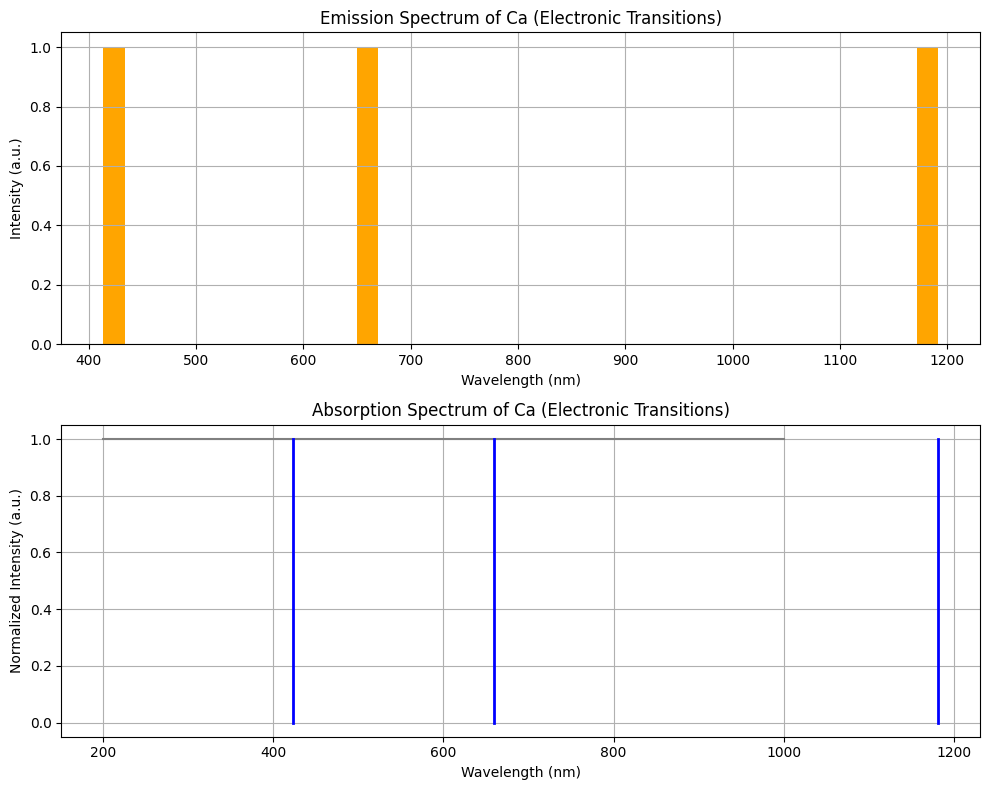

Electronic transitions for Ca (wavelengths in nm):
4p -> 4s: 423.45 nm
3d -> 4s: 659.95 nm
3d -> 4p: 1181.63 nm

Energy levels:
'4s': 0.00,  # Ground state
'3d': 1.88,  # Excited state
'4p': 2.93,  # Excited state


In [ ]:
# Calculate and visualize Spectra (provide nenergy levels - simplified and approximate values for major transitions in eV)
atom_name = 'Ca'
energy_levels = get_atomic_levels(atom_name)
spectral_analysis(atom_name, energy_levels)
format_energy_levels(energy_levels)

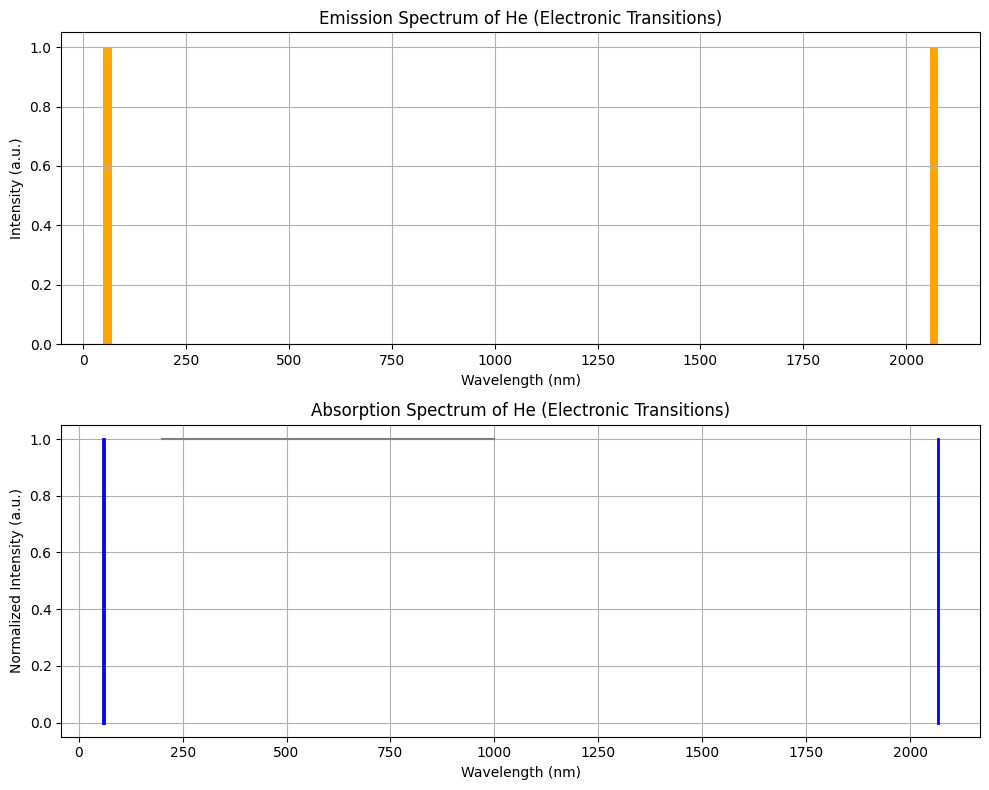

Electronic transitions for He (wavelengths in nm):
2s -> 1s: 60.17 nm
2p -> 1s: 58.47 nm
2p -> 2s: 2067.85 nm

Energy levels:
'1s': 0.00,  # Ground state
'2s': 20.62,  # Excited state
'2p': 21.22,  # Excited state


In [ ]:
# Calculate and visualize Spectra (provide nenergy levels - simplified and approximate values for major transitions in eV)
atom_name = 'He'
energy_levels = get_atomic_levels(atom_name)
spectral_analysis(atom_name, energy_levels)
format_energy_levels(energy_levels)

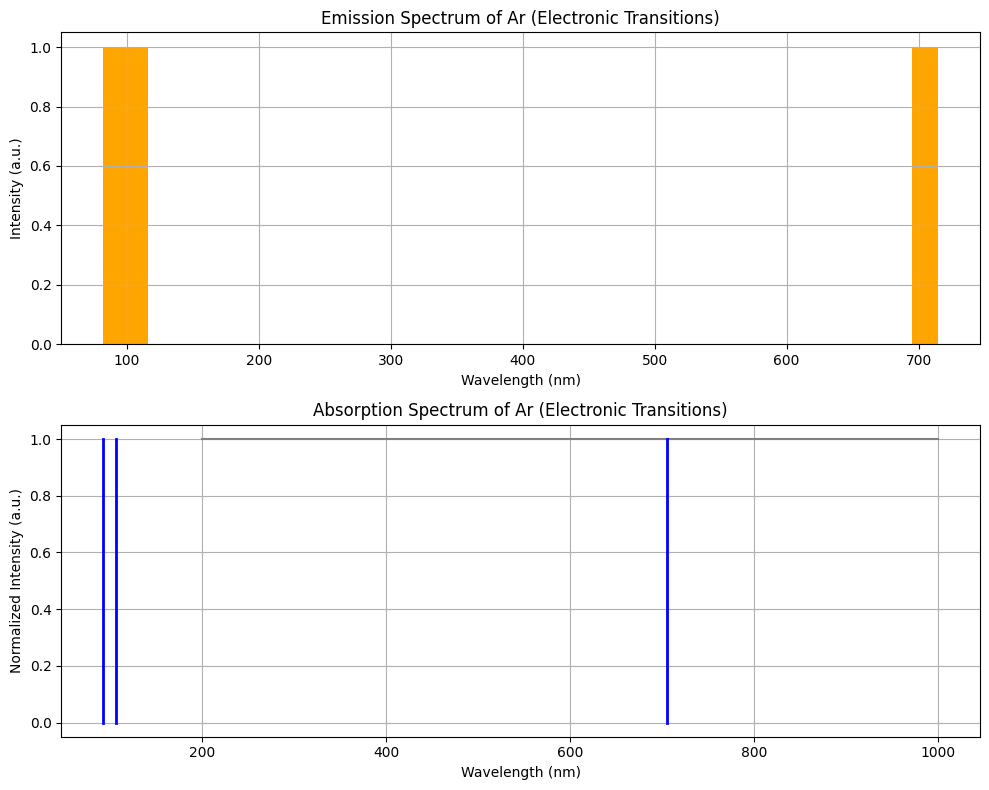

Electronic transitions for Ar (wavelengths in nm):
4s -> 3p: 105.86 nm
3d -> 3p: 92.04 nm
3d -> 4s: 704.95 nm

Energy levels:
'3p': 0.00,  # Ground state
'4s': 11.72,  # Excited state
'3d': 13.48,  # Excited state


In [ ]:
# Calculate and visualize Spectra (provide nenergy levels - simplified and approximate values for major transitions in eV)
atom_name = 'Ar'
energy_levels = get_atomic_levels(atom_name)
spectral_analysis(atom_name, energy_levels)
format_energy_levels(energy_levels)